# Laboratorio #5

* Josue Say - 228801
* Flavio Galán - 22386

## Repositorio

- [Enlace](https://github.com/JosueSay/labs-ds/tree/main/lab5)
- [Data](https://drive.google.com/file/d/1HtrCx-AEMuC6CeKCLVbERCJMxmqiPB6v/view?usp=sharing)

> **Nota:** Ejecutar el código con una versión de python 3.12.3 por lo menos para instalar los `requirements_part2.txt`

## Constantes

In [40]:
from pathlib import Path

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
DO_PIPELINE = True

# Paso temporal estándar para ambas etapas
TS_FREQ = "7D"

## Limpieza de datos

In [41]:
from pathlib import Path
import os, json, warnings
from datetime import datetime
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

In [42]:
CLEAN_DIR = BASE_DIR / "data_p2"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_ANALYSIS_DIR = CLEAN_DIR / "analysis"
CLEAN_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

META_PATH = CLEAN_DIR / "metadata.json"

# Bandera de flujo
GET_DATA = True  # True => generar limpios; False => leer limpios

# Config de limpieza
LAKES = ["Atitlan", "Amatitlan"]
INTERP_METHOD = "linear"   # interpolación temporal
Z_CAP = 3.0                # winsorize por z-score
MIN_POINTS = 8             # mínimo de puntos aceptados

# Columnas esperadas
COLMAPS = {
    "CYANO": ["CYANO_mean", "cyano", "cyano_index"],
    "NDVI":  ["NDVI_mean", "ndvi"],
    "NDWI":  ["NDWI_mean", "ndwi"],
}
DATE_COL = "date"

# Rutas posibles (tolerantes a typos)
RAW_SERIES_CANDIDATES = {
    "Amatitlan": {
        "CYANO": [
            DATA_DIR / "analysis" / "Amatitlan_CYANO_series.csv",
            DATA_DIR / "analysis" / "Amatilan_CYANO_series.csv",
        ],
        "NDVI": [
            DATA_DIR / "analysis" / "Amatitlan_NDVI_series.csv",
            DATA_DIR / "analysis" / "Amatilan_NDVI_series.csv",
        ],
        "NDWI": [
            DATA_DIR / "analysis" / "Amatitlan_NDWI_series.csv",
            DATA_DIR / "analysis" / "Amatitlan_SDWI_series.csv",
        ],
    },
    "Atitlan": {
        "CYANO": [DATA_DIR / "analysis" / "Atitlan_CYANO_series.csv"],
        "NDVI": [
            DATA_DIR / "analysis" / "Atitlan_NDVI_series.csv",
            DATA_DIR / "analysis" / "Atitlan_NDVI_seriees.csv",
        ],
        "NDWI":  [DATA_DIR / "analysis" / "Atitlan_NDWI_series.csv"],
    }
}

* **Imports y warnings**
  * `Path, os, json, warnings, datetime, numpy, pandas`: utilidades básicas para rutas, E/S, manejo de fechas y dataframes.
  * `warnings.filterwarnings("ignore")`: silencia warnings. *Opcional* (quítalo si quieres ver avisos).

* **Carpetas de salida**
  * `CLEAN_DIR = BASE_DIR / "data_p2"` y `CLEAN_ANALYSIS_DIR = CLEAN_DIR / "analysis"`: a dónde se guarda la **data limpia** que sí subes al repo.
  * `META_PATH`: JSON con metadatos de la limpieza. *No es obligatorio*, pero útil para trazabilidad.

* **Bandera de flujo**
  * `GET_DATA = True`:
    * **True** -> corre la limpieza y vuelve a generar los CSV limpios.
    * **False** -> solo lee lo ya limpio de `data_p2/`.
    * **Buena práctica**: dejarlo en False después del primer corrido estable.

* **Configuración de limpieza**
  * `LAKES = ["Atitlan", "Amatitlan"]`: lista de lagos a procesar.
  * `INTERP_METHOD = "linear"`: método de interpolación temporal al remuestrear (p.ej. `"time"`, `"nearest"`, `"spline"`…).
  * `Z_CAP = 3.0`: winsorize suave (recorte por z-score) sobre el índice de cianobacteria para mitigar outliers.
  * `MIN_POINTS = 8`: mínimo de observaciones tras limpieza para aceptar la serie.

* **Columnas esperadas**
  * `COLMAPS`: mapeo flexible de nombres de columnas -> estándar interno (`value`).

* **Rutas de entrada tolerantes a typos**
  * `RAW_SERIES_CANDIDATES`: lista de candidatos por lago e índice (CYANO/NDVI/NDWI).
    * Incluye variantes con typos (`Amatilan`, `SDWI`, `seriees`).
    * El código escogerá el primero que exista.

* **Sugerencias prácticas**
  * Corre una vez con `GET_DATA=True`; revisa los CSV limpios; luego fija `GET_DATA=False`.
  * Si tu serie es muy irregular, considera `INTERP_METHOD="time"` o remuestrear a `'14D'`.

In [43]:
def findFirstExisting(paths):
    for p in paths:
        if p.exists():
            return p
    return None

Devuelve **el primer path que exista** en la lista `paths`.

* Recorre `paths` en orden.
* Si `p.exists()` es True, retorna `p`.
* Si ninguno existe, retorna `None`.
  Útil para escoger entre rutas candidatas (p. ej., con typos).


In [44]:
def pickFirstExistingColumn(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

Devuelve **el primer nombre de columna** de `candidates` que esté presente en `df`.

* Recorre `candidates` en orden.
* Si `c` está en `df.columns`, lo retorna.
* Si ninguna coincide, retorna `None`.
  Sirve para mapear columnas cuando los CSV pueden tener nombres variables/typos.

In [45]:
def loadSeries(path, valueColCandidates, dateCol=DATE_COL):
    if path is None or (not path.exists()):
        return None
    df = pd.read_csv(path)
    if dateCol not in df.columns:
        raise ValueError(f"Falta columna '{dateCol}' en {path.name}")
    valueCol = pickFirstExistingColumn(df, valueColCandidates)
    if valueCol is None:
        raise ValueError(f"No se halló columna de valores en {path.name}. Candidatas={valueColCandidates}")
    df[dateCol] = pd.to_datetime(df[dateCol])
    df = df[[dateCol, valueCol]].drop_duplicates()
    df = df.sort_values(dateCol).set_index(dateCol)
    df = df.rename(columns={valueCol: "value"})
    df = df.dropna(subset=["value"])
    return df

Carga una serie desde CSV y la estandariza.

* Si `path` no existe -> **return None**.
* Lee el CSV y verifica que exista la columna de fecha `dateCol`; si no, **lanza error**.
* Busca la **primera** columna de valores válida con `pickFirstExistingColumn(valueColCandidates)`; si no hay, **lanza error**.
* Convierte fechas a `datetime`, selecciona `[dateCol, valueCol]`, **elimina duplicados**, **ordena por fecha** y pone la fecha como **índice**.
* Renombra la columna de valores a `"value"` y **elimina NaN** en esa columna.
* Devuelve un `DataFrame` limpio y listo para remuestreo/modelado.

In [46]:
def resampleInterpolate(df, freq=TS_FREQ, method=INTERP_METHOD):
    if df is None or df.empty:
        return df
    df_rs = df.resample(freq).mean()
    return df_rs.interpolate(method=method, limit_direction="both")

Carga una serie desde CSV y la estandariza.

* Si `path` no existe -> **return None**.
* Lee el CSV y verifica que exista la columna de fecha `dateCol`; si no, **lanza error**.
* Busca la **primera** columna de valores válida con `pickFirstExistingColumn(valueColCandidates)`; si no hay, **lanza error**.
* Convierte fechas a `datetime`, selecciona `[dateCol, valueCol]`, **elimina duplicados**, **ordena por fecha** y pone la fecha como **índice**.
* Renombra la columna de valores a `"value"` y **elimina NaN** en esa columna.
* Devuelve un `DataFrame` limpio y listo para remuestreo/modelado.

In [47]:
def capOutliersZ(df, col="value", z=Z_CAP):
    if df is None or df.empty: 
        return df
    s = df[col]
    if s.std(ddof=0) == 0 or s.isna().all():
        return df
    zscores = (s - s.mean()) / s.std(ddof=0)
    lower = s[zscores >= -z].min()
    upper = s[zscores <=  z].max()
    df[col] = s.clip(lower=lower, upper=upper)
    return df

Hace **winsorization** por *z-score* para limitar outliers en `col`.

* Si `df` está vacío, desviación estándar = 0 o todo NaN -> **no cambia nada**.
* Calcula `zscore` de la serie.
* Define límites como el **mínimo/máximo** dentro de `|z| ≤ z` (`lower`, `upper`).
* **Recorta** (`clip`) los valores fuera de esos límites a `lower`/`upper`.
* Devuelve el `DataFrame` con la columna suavizada (sin borrar filas).

In [48]:
def buildCleanForLake(lake):
    """Genera df limpio con columnas: cyano, ndvi?, ndwi? (índice tiempo uniforme)."""
    paths = RAW_SERIES_CANDIDATES[lake]
    meta = {"lake": lake, "source_paths": {}, "steps": []}

    # cargar series crudas (con tolerancia a typos)
    p_cy = findFirstExisting(paths["CYANO"])
    p_nv = findFirstExisting(paths["NDVI"])
    p_nw = findFirstExisting(paths["NDWI"])
    meta["source_paths"] = {"CYANO": str(p_cy), "NDVI": str(p_nv), "NDWI": str(p_nw)}

    cy = loadSeries(p_cy, COLMAPS["CYANO"]) if p_cy else None
    ndvi = loadSeries(p_nv, COLMAPS["NDVI"]) if p_nv else None
    ndwi = loadSeries(p_nw, COLMAPS["NDWI"]) if p_nw else None
    meta["steps"].append({"loaded": {
        "CYANO": 0 if cy is None else int(cy.shape[0]),
        "NDVI":  0 if ndvi is None else int(ndvi.shape[0]),
        "NDWI":  0 if ndwi is None else int(ndwi.shape[0]),
    }})

    # remuestreo + interpolación
    cy = resampleInterpolate(cy.rename(columns={"value":"cyano"}))
    ndvi = resampleInterpolate(ndvi.rename(columns={"value":"ndvi"})) if ndvi is not None else None
    ndwi = resampleInterpolate(ndwi.rename(columns={"value":"ndwi"})) if ndwi is not None else None
    meta["steps"].append({"resample": TS_FREQ, "interpolate": INTERP_METHOD})

    # merge
    if cy is None or cy.empty:
        raise ValueError(f"{lake}: no hay serie CYANO válida")
    df = cy.copy()
    if ndvi is not None: df = df.join(ndvi, how="left")
    if ndwi is not None: df = df.join(ndwi, how="left")

    # capping outliers sobre cyano
    df["cyano"] = df["cyano"].astype(float)
    df = capOutliersZ(df, col="cyano", z=Z_CAP)
    meta["steps"].append({"z_cap": Z_CAP})

    # mínimos
    df = df.dropna(subset=["cyano"])
    if df.shape[0] < MIN_POINTS:
        raise ValueError(f"{lake}: muy pocos puntos tras limpieza ({df.shape[0]} < {MIN_POINTS})")

    # guardar limpio
    out_csv = CLEAN_ANALYSIS_DIR / f"{lake}_CYANO_clean.csv"
    df.to_csv(out_csv, index=True, date_format="%Y-%m-%d")
    meta.update({
        "output_csv": str(out_csv),
        "rows": int(df.shape[0]),
        "date_min": df.index.min().strftime("%Y-%m-%d"),
        "date_max": df.index.max().strftime("%Y-%m-%d")
    })
    return df, meta

Genera y guarda la **serie limpia por lago** (CYANO + exógenas si hay) con tiempo uniforme.

* **Entrada:** `lake` (str).
* **Busca archivos fuente** tolerando typos (`RAW_SERIES_CANDIDATES`) con `findFirstExisting`.
* **Carga** cada serie (`CYANO`, `NDVI`, `NDWI`) con `loadSeries` y registra metadatos.
* **Remuestrea** a `TS_FREQ` e **interpora** vacíos (`INTERP_METHOD`).
* **Une** las series por índice de fecha (left join sobre CYANO).
* **Suaviza outliers** en `cyano` con `capOutliersZ(z=Z_CAP)`.
* **Valida** mínimo de puntos (`MIN_POINTS`) y elimina NaN en `cyano`.
* **Guarda** CSV limpio en `CLEAN_ANALYSIS_DIR/{lake}_CYANO_clean.csv` y devuelve `(df, meta)`.

In [49]:
def runCleanPipeline():
    allMeta = {"ts_freq": TS_FREQ, "interp": INTERP_METHOD, "z_cap": Z_CAP, "min_points": MIN_POINTS, "lakes": {}}
    for lake in LAKES:
        df, meta = buildCleanForLake(lake)
        allMeta["lakes"][lake] = meta
    with open(META_PATH, "w", encoding="utf-8") as f:
        json.dump(allMeta, f, ensure_ascii=False, indent=2)
    print(f"Datos limpios en: {CLEAN_ANALYSIS_DIR}")
    return allMeta

Ejecuta la **limpieza completa** para todos los lagos y guarda metadatos.

* Inicializa `allMeta` con la config global y un dict para cada lago.
* Recorre `LAKES`, llama `buildCleanForLake(lake)` y almacena su `meta`.
* Escribe `allMeta` en `META_PATH` (JSON de trazabilidad).
* Imprime confirmación de que los CSV limpios están en `CLEAN_ANALYSIS_DIR`.
* Devuelve `allMeta`.

In [50]:
def loadCleanOrBuild(getData=GET_DATA):
    if getData:
        return runCleanPipeline()
    missing = [lake for lake in LAKES if not (CLEAN_ANALYSIS_DIR / f"{lake}_CYANO_clean.csv").exists()]
    if missing:
        raise FileNotFoundError(f"Faltan limpios: {missing}. Pon GET_DATA=True para generarlos.")
    print("Leyendo data limpia existente…")
    metaSafe = {}
    if META_PATH.exists():
        with open(META_PATH, "r", encoding="utf-8") as f:
            metaSafe = json.load(f)
    return metaSafe


Carga la data limpia o la genera, según la bandera.

* Si `getData=True` -> ejecuta `runCleanPipeline()` y **construye** todo.
* Si `getData=False` -> **verifica** que existan los CSV limpios por lago; si faltan, **lanza error**.
* Si existen, **lee** `metadata.json` (si está) y retorna ese diccionario (`metaSafe`).

In [51]:
meta = loadCleanOrBuild(GET_DATA)

Datos limpios en: d:\repositorios\UVG\2025\labs-ds\lab5\data_p2\analysis


## Inciso 10

### **Objetivo**

Predecir el **índice de cianobacteria** (*CYANO index*) a futuro usando un modelo de series temporales.
La predicción es por lago y a nivel **promedio de todo el lago** (no por píxel).

### **Entradas necesarias**

* Archivos en `data/analysis`:
  * `Atitlan_CYANO_series.csv`
  * `Amatitlan_CYANO_series.csv`

* Cada CSV debe tener al menos:

  * `date` -> fecha de observación.
  * `cyano_index` -> valor promedio o percentil (según definiste en la primera parte con `CYANO_METRIC`).

* Series de NDVI o NDWI para usar como variables exógenas (`Atitlan_NDVI_series.csv`, etc.).

### **Flujo detallado**

1. **Carga de datos**

   * Leer cada CSV de `*_CYANO_series.csv`.
   * Convertir la columna `date` a `datetime` y usarla como índice.
   * Si hay huecos en las fechas, re-muestrear a una frecuencia fija (`'7D'`, `'D'`, etc.) y aplicar interpolación.

2. **Exploración**

   * Graficar la serie para ver tendencia, estacionalidad y posibles valores atípicos.
   * Descomponer la serie (`seasonal_decompose`) para verificar si hay estacionalidad clara.

3. **División en entrenamiento y validación**

   * Usar un **split temporal** (no aleatorio) para evitar fugas de información.
   * Ej.: entrenar con datos hasta el `2025-07-15` y validar con el resto.

4. **Selección del modelo**

   * **Opción 1:** `pmdarima.auto_arima` -> detecta automáticamente parámetros de ARIMA/SARIMA.
   * **Opción 2:** `Prophet` -> más rápido para estacionalidad compleja.
   * **Opción 3:** LSTM (`tensorflow.keras`) -> para patrones no lineales (requiere más datos).
   * Se pueden incluir **exógenas** (NDVI, NDWI) si están sincronizadas en fechas.

5. **Entrenamiento**

   * Ajustar el modelo con el conjunto de entrenamiento.
   * Guardar los parámetros o pesos (para reutilizar en inciso 12).

6. **Predicción**

   * Generar pronósticos para el horizonte definido (`FORECAST_HORIZON` días).
   * Evaluar contra los datos de validación con métricas: MAE, RMSE.

7. **Visualización**

   * Gráfico con:

     * Serie real de entrenamiento.
     * Predicción sobre el periodo de validación.
     * Pronóstico futuro (horizonte).

8. **Salida**

   * CSV con columnas: `date`, `cyano_index_pred`.
   * Gráfico `.png` con comparación real vs predicho.
   * Modelo guardado (`joblib.dump` o `.pkl`).

In [52]:
from pathlib import Path
import warnings, pickle
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
from pmdarima.model_selection import train_test_split as arima_train_test_split

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10,4)

In [53]:
FORECAST_DIR = (BASE_DIR / "data_p2" / "forecast")
FORECAST_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
FORECAST_HORIZON_DAYS = 30
TRAIN_TEST_SPLIT_DATE = "2025-07-15"  # corte temporal para validación
SAVE_MODEL = True

In [54]:
def splitTrainTestByDate(df, splitDate):
    """Separa por fecha índice (datetime). Devuelve (train, test)."""
    splitDate = pd.to_datetime(splitDate)
    train = df[df.index <= splitDate].copy()
    test  = df[df.index  > splitDate].copy()
    return train, test

In [55]:
def fitAutoArima(trainY, trainExog=None, seasonal=True, m=4):
    """
    Ajusta auto_arima:
      - seasonal=True y m=4 ~ estacionalidad mensual aproximada en frecuencia semanal.
    """
    model = pm.auto_arima(
        trainY,
        exogenous=trainExog,
        seasonal=seasonal,
        m=m,
        start_p=0, start_q=0, start_P=0, start_Q=0,
        max_p=3, max_q=3, max_P=2, max_Q=2,
        d=None, D=None,
        trace=False,
        error_action="ignore",
        suppress_warnings=True,
        stepwise=True,
        random_state=RANDOM_SEED
    )
    return model

In [56]:
def forecastLake(lake, horizonDays=FORECAST_HORIZON_DAYS, splitDate=TRAIN_TEST_SPLIT_DATE, saveModel=SAVE_MODEL):
    """Entrena y pronostica para un lago usando cyano (y exógenas si están)."""
    cleanPath = CLEAN_ANALYSIS_DIR / f"{lake}_CYANO_clean.csv"
    df = pd.read_csv(cleanPath, parse_dates=[0], index_col=0)
    # separar target y exógenas
    y = df["cyano"].astype(float)
    exog_cols = [c for c in ["ndvi","ndwi"] if c in df.columns]
    X = df[exog_cols] if exog_cols else None

    # split temporal
    trainIdx, testIdx = splitTrainTestByDate(df, splitDate)
    y_train = y.loc[trainIdx.index]
    y_test  = y.loc[testIdx.index]
    X_train = X.loc[trainIdx.index] if X is not None else None
    X_test  = X.loc[testIdx.index]  if X is not None else None

    # entrenar
    model = fitAutoArima(y_train, trainExog=X_train, seasonal=True, m=4)

    # predicción en test (backtest corto)
    n_test = len(y_test)
    preds_test = None
    if n_test > 0:
        preds_test = model.predict(n_periods=n_test, exogenous=X_test if X_test is not None else None)
        mae = np.mean(np.abs(preds_test - y_test.values))
        rmse = np.sqrt(np.mean((preds_test - y_test.values)**2))
    else:
        mae, rmse = np.nan, np.nan

    # pronóstico futuro (horizonte en días -> convertir a pasos de la frecuencia)
    # si la frecuencia es semanal ('7D'), n_periods = ceil(horizonDays / 7)
    step_days = pd.to_timedelta(TS_FREQ).days if "D" in TS_FREQ else 7
    n_periods_future = int(np.ceil(horizonDays / step_days))
    future_exog = None
    if X is not None:
        # repetir último valor como proxy (puedes reemplazar por forecast de NDVI/NDWI si tienes)
        last_row = X.iloc[[-1]].values
        future_exog = np.repeat(last_row, repeats=n_periods_future, axis=0)

    preds_future = model.predict(n_periods=n_periods_future, exogenous=future_exog)

    # construir dataframes de salida
    df_pred_test = None
    if n_test > 0:
        df_pred_test = pd.DataFrame({
            "date": y_test.index,
            "cyano_real": y_test.values,
            "cyano_pred": preds_test
        }).set_index("date")

    last_date = df.index[-1]
    future_idx = pd.date_range(last_date + pd.to_timedelta(TS_FREQ), periods=n_periods_future, freq=TS_FREQ)
    df_pred_future = pd.DataFrame({"date": future_idx, "cyano_pred": preds_future}).set_index("date")

    # guardar
    out_pred_test = FORECAST_DIR / f"{lake}_cyano_pred_test.csv"
    out_pred_future = FORECAST_DIR / f"{lake}_cyano_forecast_{horizonDays}d.csv"
    if df_pred_test is not None:
        df_pred_test.to_csv(out_pred_test, date_format="%Y-%m-%d")
    df_pred_future.to_csv(out_pred_future, date_format="%Y-%m-%d")

    model_path = FORECAST_DIR / f"{lake}_arima_model.pkl"
    if saveModel:
        with open(model_path, "wb") as f:
            pickle.dump(model, f)

    # gráfico rápido
    ax = y.plot(label="real", linewidth=1)
    if df_pred_test is not None:
        df_pred_test["cyano_pred"].plot(ax=ax, label="pred (val)", linestyle="--")
    df_pred_future["cyano_pred"].plot(ax=ax, label="forecast", linestyle=":")
    plt.title(f"{lake} — CYANO (real / val / forecast)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    metrics = {"lake": lake, "mae": float(mae), "rmse": float(rmse),
               "n_train": int(len(y_train)), "n_test": int(len(y_test)),
               "freq": TS_FREQ, "horizon_days": int(horizonDays),
               "exog_used": exog_cols}
    print(metrics)

    # guardar métricas
    with open(FORECAST_DIR / f"{lake}_forecast_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, ensure_ascii=False, indent=2)

    return {
        "model_path": str(model_path),
        "pred_test_csv": str(out_pred_test) if n_test > 0 else None,
        "forecast_csv": str(out_pred_future),
        "metrics": metrics
    }

In [57]:
def runForecastPipeline():
    results = {}
    for lake in LAKES:
        results[lake] = forecastLake(lake)
    return results


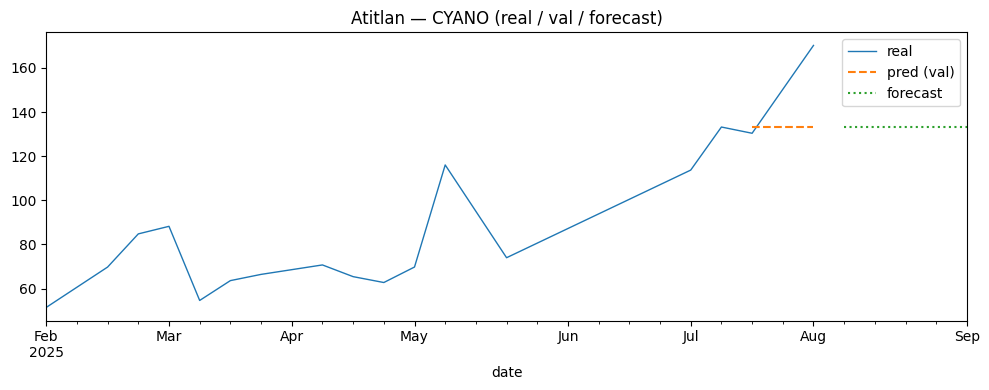

{'lake': 'Atitlan', 'mae': 18.96931266784668, 'rmse': 23.583249462696283, 'n_train': 23, 'n_test': 3, 'freq': '7D', 'horizon_days': 30, 'exog_used': ['ndvi', 'ndwi']}


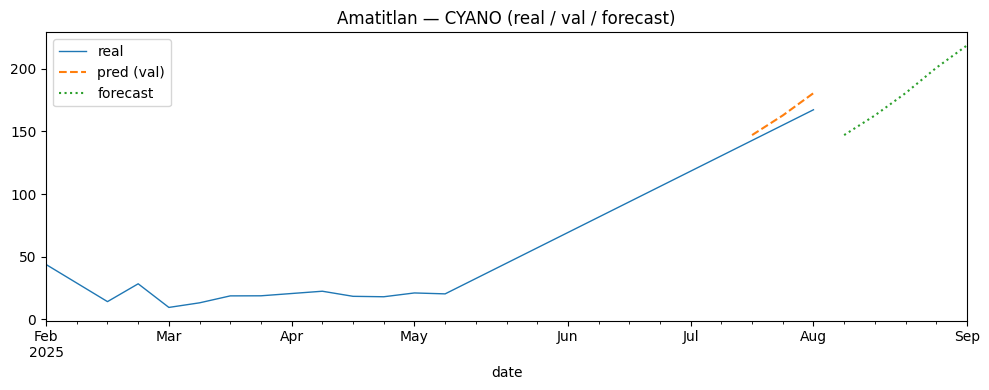

{'lake': 'Amatitlan', 'mae': 8.44299396705791, 'rmse': 9.221359550928524, 'n_train': 23, 'n_test': 3, 'freq': '7D', 'horizon_days': 30, 'exog_used': ['ndvi', 'ndwi']}


{'Atitlan': {'model_path': 'd:\\repositorios\\UVG\\2025\\labs-ds\\lab5\\data_p2\\forecast\\Atitlan_arima_model.pkl',
  'pred_test_csv': 'd:\\repositorios\\UVG\\2025\\labs-ds\\lab5\\data_p2\\forecast\\Atitlan_cyano_pred_test.csv',
  'forecast_csv': 'd:\\repositorios\\UVG\\2025\\labs-ds\\lab5\\data_p2\\forecast\\Atitlan_cyano_forecast_30d.csv',
  'metrics': {'lake': 'Atitlan',
   'mae': 18.96931266784668,
   'rmse': 23.583249462696283,
   'n_train': 23,
   'n_test': 3,
   'freq': '7D',
   'horizon_days': 30,
   'exog_used': ['ndvi', 'ndwi']}},
 'Amatitlan': {'model_path': 'd:\\repositorios\\UVG\\2025\\labs-ds\\lab5\\data_p2\\forecast\\Amatitlan_arima_model.pkl',
  'pred_test_csv': 'd:\\repositorios\\UVG\\2025\\labs-ds\\lab5\\data_p2\\forecast\\Amatitlan_cyano_pred_test.csv',
  'forecast_csv': 'd:\\repositorios\\UVG\\2025\\labs-ds\\lab5\\data_p2\\forecast\\Amatitlan_cyano_forecast_30d.csv',
  'metrics': {'lake': 'Amatitlan',
   'mae': 8.44299396705791,
   'rmse': 9.221359550928524,
   'n_

In [58]:
results = runForecastPipeline()
results